# Analysis results across session

In [1]:
import os
import numpy as np
import mat73
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
# all_sessions = [
#     '20251202-SL412-Random1_g0',
# #     '20251203-SL412-Random2_g0',
# #     '20251205-SL412-Random3_g0',
# #     '20251206-SL412-Random4_g0',
# #     '20251207-SL412-Reward1_g0',
# #     '20251208-SL412-Reward2_g0',
# #     '20251209-SL412-Reward3_g0',
# #     '20251210-SL412-Reward4_g0',
# #     '20251211-SL412-Punish1_g0',
# #     '20251212-SL412-Punish2_g0',
# #     '20251213-SL412-Punish3_g0',
# #     '20251214-SL412-Punish4_g0',
# #     '20251215-SL412-Reward5_g0',
# #     '20251216-SL412-Punish5_g0',
# #     '20251217-SL412-Reward6_g0',
# #     '20251218-SL412-Punish6_g0',
# ]

session_name = '20251202-SL412-Random1_g0'

# Read data
exp_name = '202512-Ephys-LHb'
session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
spike_path = os.path.join(session_path, rf'AIND_{session_name}')
nwb_path = os.path.join(session_path, 'nwb','ecephys_session_block0_recording1.nwb')
save_folder = os.path.join(session_path, 'results')

print('Analyzing session: ', session_name)
print('Session path: ', session_path)
print('Spike path: ', spike_path)
print('Save folder: ', save_folder)

Analyzing session:  20251202-SL412-Random1_g0
Session path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0
Spike path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/AIND_20251202-SL412-Random1_g0
Save folder:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/results


In [3]:
# h5_path = save_folder + f'/analysis-{session_name}.h5'
# session_data = ndap.load_session_data(h5_path, lazy=False, verbose=False)

### Plot units on NP2 channel map

Parse the session `.imro` file, map each AP channel index to probe (x, y), then overlay selected `unit_ids` using their `peak_channel` from `cluster_info`.

In [4]:
# Create channel map
import re

# --- Parse IMRO file to build NP2 channel map ---
imro_path = '/Users/shunli/Projects/pyNeuroDAP/Data/NP2-LHb-3500.imro'
with open(imro_path) as f:
    imro_raw = f.read().strip()

# NP2 multishank (type 2013): each entry is (chan_id shank_id bank ref_id electrode_id)
entries = re.findall(r'\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)', imro_raw)

NP2_SHANK_PITCH = 250  # um between shanks
NP2_COL_PITCH = 32     # um between columns within a shank
NP2_ROW_PITCH = 15     # um between rows

channel_map = []
for chan_id, shank_id, bank, ref_id, elec_id in entries:
    chan_id, shank_id, elec_id = int(chan_id), int(shank_id), int(elec_id)
    col = elec_id % 2
    row = elec_id // 2
    x = shank_id * NP2_SHANK_PITCH + col * NP2_COL_PITCH
    y = row * NP2_ROW_PITCH
    channel_map.append({'channel_id': chan_id, 'shank_id': shank_id,
                        'electrode_id': elec_id, 'x': x, 'y': y})

channel_df = pd.DataFrame(channel_map)

In [5]:
import ast
import re
import pandas as pd

optotag_path = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412/optotag_results_all_sessions.txt'

# ---------------------------
# Choose what to load:
#   - session_selector = session_name   -> one specific session
#   - session_selector = "all"          -> all sessions
#   - session_selector = None           -> all sessions
# ---------------------------
# session_selector = session_name
session_selector = "all"

with open(optotag_path, 'r') as f:
    txt = f.read()

# Parse every session block in the file
pattern = re.compile(
    r"Session:\s*(?P<session>.+?)\s*[\r\n]+"
    r"[\s\S]*?Tagged units\s*\(unit_ids\)\s*:\s*(?P<tagged>\[[^\]]*\])"
    r"[\s\S]*?Peak channels\s*:\s*(?P<peaks>\[[^\]]*\])",
    re.MULTILINE
)

rows = []

for m in pattern.finditer(txt):
    session = m.group("session").strip()
    tagged_units = ast.literal_eval(m.group("tagged"))
    peak_channels = ast.literal_eval(m.group("peaks"))

    if len(tagged_units) != len(peak_channels):
        raise ValueError(
            f"Tagged units and peak channels length mismatch for {session}: "
            f"{len(tagged_units)} vs {len(peak_channels)}"
        )

    # Keep only the requested session unless using all sessions
    if session_selector not in [None, "all"] and session != session_selector:
        continue

    for unit_id, peak_channel in zip(tagged_units, peak_channels):
        rows.append({
            "session": session,
            "unit_ids": unit_id,
            "peak_channel": peak_channel
        })

if not rows:
    if session_selector in [None, "all"]:
        raise ValueError(f"No sessions found in {optotag_path}")
    else:
        raise ValueError(f"Could not find session '{session_selector}' in {optotag_path}")

unit_peak = pd.DataFrame(rows)
unit_peak = unit_peak.merge(
    channel_df,
    left_on='peak_channel',
    right_on='channel_id',
    how='left'
)

# Optional:
# # If you selected a single session and don't want the session column:
# if session_selector not in [None, "all"]:
#     unit_peak = unit_peak.drop(columns=["session"])

# # --- Select units and find their peak channels ---
# selected_units = [4, 203, 302]
# unit_peak = cluster_info[cluster_info['unit_ids'].isin(selected_units)][['unit_ids', 'peak_channel']].copy()
# unit_peak = unit_peak.merge(channel_df, left_on='peak_channel', right_on='channel_id', how='left')

# unit_peak

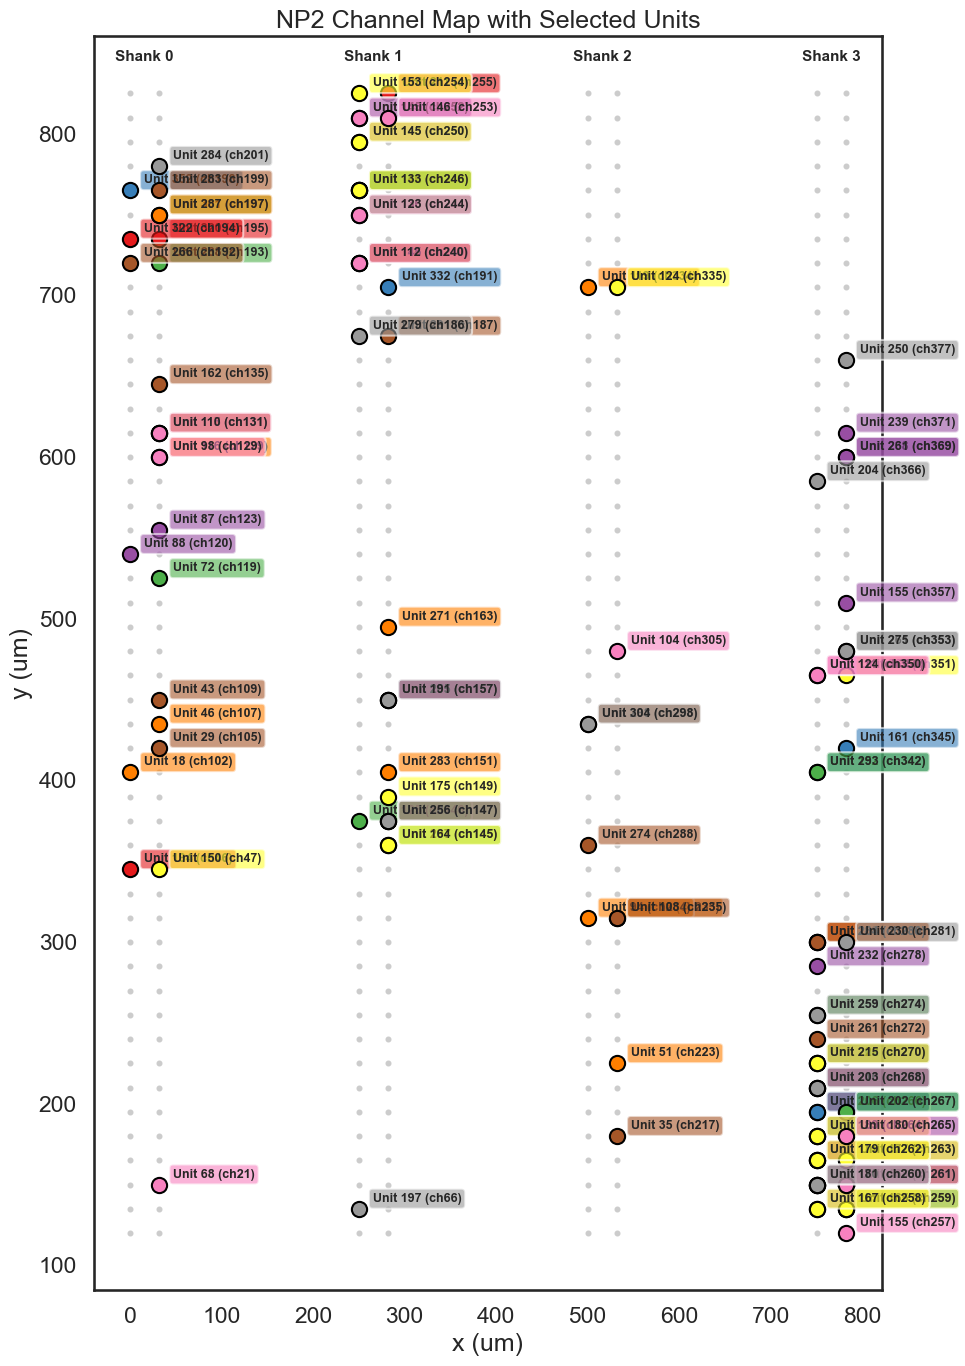

In [6]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14))

for shank_id, grp in channel_df.groupby('shank_id'):
    ax.scatter(grp['x'], grp['y'], s=8, c='#ccc', zorder=1)

cmap = plt.cm.Set1
for i, (_, row) in enumerate(unit_peak.iterrows()):
    color = cmap(i / max(len(unit_peak) - 1, 1))
    ax.scatter(row['x'], row['y'], s=120, c=[color], edgecolors='k',
               linewidths=1.5, zorder=3)
    ax.annotate(f"Unit {int(row['unit_ids'])} (ch{int(row['peak_channel'])})",
                (row['x'], row['y']), fontsize=9, fontweight='bold',
                xytext=(10, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc=color, alpha=0.6))

for sid in sorted(channel_df['shank_id'].unique()):
    cx = sid * NP2_SHANK_PITCH + NP2_COL_PITCH / 2
    ax.text(cx, channel_df['y'].max() + 20, f'Shank {sid}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_title('NP2 Channel Map with Selected Units')
plt.tight_layout()
plt.show()

# print(unit_peak[['unit_ids', 'peak_channel', 'shank_id', 'electrode_id', 'x', 'y']])
# Save figure as pdf
results_folder = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412'
fig.savefig(os.path.join(results_folder, 'optotag_channel_map.pdf'), dpi=300)


### Plot PSTH near blue opto


In [7]:
# event = optotag_onsets
# # event = blueLaser_onsets[:50] # for reward1 and after
# # event = blueLaser_onsets[-50:] # for random4

# event_label = 'blue opto'
# bin_size_ms = 5             # in ms
# time_range = (-0.05,0.1)    # in sec
# event_color = 'tab:cyan'
# event_duration = 0.01        # in sec

# # Run salt to find optotagged units
# salt_results = ndap.run_salt(
#     spikes, event,
#     test_window=0.02,
#     bin_size=0.001,
#     baseline_duration=1.0,
#     same_system=False, params=params,
#     include_units=good_units,
#     unit_ids=good_unit_ids,
#     expected_direction='excite',
#     reliability_threshold=0.25,  # optional: fires on ≥25% of trials
# )
# tagged_units = salt_results['unit_ids'][salt_results['tagged']]
# print(f"Tagged units: {tagged_units}")

# # Print rows of optotagged units (show unit_ids, global_unit_ids, peak_channel, default_qc, manual_quality, quality)
# # cols_to_show = ['unit_ids', 'global_unit_ids', 'peak_channel', 'quality']
# # print(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), cols_to_show])

# # Print the range of peak_channel for the optotagged units
# print(f"Peak channel range for optotagged units: {np.min(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])} to {np.max(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])}")

# # Plot PSTH of blue opto
# # ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
# #                     good_units=good_units, good_unit_ids=good_unit_ids,
# #                     same_system=False, params=params, bin_size_ms=bin_size_ms,
# #                     event_color=event_color, event_duration=event_duration, event_label=event_label,
# #                     save_figure=False, save_folder=save_folder)


### Plot PSTH of events

In [8]:
# # Plot PSTH aligned to water
# event = water_lick_onsets
# event_label = 'water'
# bin_size_ms = 5             # in ms
# time_range = (-0.5,2)       # in sec
# event_color = 'tab:cyan'
# event_duration = 0.2        # in sec

# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)

### Plot response changes during event period across trials

In [55]:
session_type = 'repeat'
event_key = 'opto_only_baseline'
n_grouped_trials = 5
results_folder = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412'

repeat_sessions = [
    # '20251202-SL412-Random1_g0',
    '20251203-SL412-Random2_g0',
    '20251205-SL412-Random3_g0',
    '20251206-SL412-Random4_g0',
    # '20251207-SL412-Reward1_g0',
    '20251208-SL412-Reward2_g0',
    '20251209-SL412-Reward3_g0',
    '20251210-SL412-Reward4_g0',
    # '20251211-SL412-Punish1_g0',
    '20251212-SL412-Punish2_g0',
    '20251213-SL412-Punish3_g0',
    '20251214-SL412-Punish4_g0',
    # '20251215-SL412-Reward5_g0',
    # '20251216-SL412-Punish5_g0',
    # '20251217-SL412-Reward6_g0',
    # '20251218-SL412-Punish6_g0',
]

reversal_sessions = [
    # '20251202-SL412-Random1_g0',
    '20251203-SL412-Random2_g0',
    '20251205-SL412-Random3_g0',
    '20251206-SL412-Random4_g0',
    '20251207-SL412-Reward1_g0',
    # '20251208-SL412-Reward2_g0',
    # '20251209-SL412-Reward3_g0',
    # '20251210-SL412-Reward4_g0',
    '20251211-SL412-Punish1_g0',
    # '20251212-SL412-Punish2_g0',
    # '20251213-SL412-Punish3_g0',
    # '20251214-SL412-Punish4_g0',
    '20251215-SL412-Reward5_g0',
    '20251216-SL412-Punish5_g0',
    '20251217-SL412-Reward6_g0',
    '20251218-SL412-Punish6_g0',
]

all_sessions = [
    '20251202-SL412-Random1_g0',
    '20251203-SL412-Random2_g0',
    '20251205-SL412-Random3_g0',
    '20251206-SL412-Random4_g0',
    '20251207-SL412-Reward1_g0',
    '20251208-SL412-Reward2_g0',
    '20251209-SL412-Reward3_g0',
    '20251210-SL412-Reward4_g0',
    '20251211-SL412-Punish1_g0',
    '20251212-SL412-Punish2_g0',
    '20251213-SL412-Punish3_g0',
    '20251214-SL412-Punish4_g0',
    '20251215-SL412-Reward5_g0',
    '20251216-SL412-Punish5_g0',
    '20251217-SL412-Reward6_g0',
    '20251218-SL412-Punish6_g0',
]

# Initialize results dictionary
random_event_rates_grouped = []
random_event_rates_diff_grouped = []
random_event_rates_slopes = []
random_mod_index_grouped = []
random_mod_index_diff_grouped = []
random_mod_index_slopes = []
random_mod_index = []
reward_event_rates_grouped = []
reward_event_rates_diff_grouped = []
reward_event_rates_slopes = []
reward_mod_index_grouped = []
reward_mod_index_diff_grouped = []
reward_mod_index_slopes = []
reward_mod_index = []
punish_event_rates_grouped = []
punish_event_rates_diff_grouped = []
punish_event_rates_slopes = []
punish_mod_index_grouped = []
punish_mod_index_diff_grouped = []
punish_mod_index_slopes = []
punish_mod_index = []

# Determine analysis sessions
if session_type == 'reversal':
    sessions = reversal_sessions
elif session_type == 'repeat':
    sessions = repeat_sessions
elif session_type == 'all':
    sessions = all_sessions

# Determine event key
if event_key == 'opto_only' or event_key == 'pair' or event_key == 'opto_only_baseline' or event_key == 'pair_baseline':
    event_key_random = 'red_opto'
elif event_key == 'tone_only' or event_key == 'tone_only_baseline':
    event_key_random = 'tone'

for session_name in sessions:
    # Load data from analysis file
    session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
    save_folder = os.path.join(session_path, 'results')
    h5_path = save_folder + f'/analysis-{session_name}.h5'
    session_data = ndap.load_session_data(h5_path, groups=['trials_spikes'], verbose=False)

    if 'RANDOM' in session_name.upper():
        session_event_rates = session_data['trials_spikes'][event_key_random]['event_rates']
        session_event_rates_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials)
        session_event_rates_diff_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials, n_baseline_trials=5)
        random_event_rates_grouped.append(session_event_rates_grouped)
        random_event_rates_diff_grouped.append(session_event_rates_diff_grouped)
        random_event_rates_slopes.append(session_data['trials_spikes'][event_key_random]['event_rates_slopes'])

        session_mod_index = session_data['trials_spikes'][event_key_random]['mod_results']['mod_index_per_trial']
        session_mod_index_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials)
        session_mod_index_diff_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials, n_baseline_trials=5)
        random_mod_index_grouped.append(session_mod_index_grouped)
        random_mod_index_diff_grouped.append(session_mod_index_diff_grouped)
        random_mod_index_slopes.append(session_data['trials_spikes'][event_key_random]['mod_index_slopes'])
        random_mod_index.append(session_data['trials_spikes'][event_key_random]['mod_results']['mod_index'])
        
    elif 'REWARD' in session_name.upper():
        session_event_rates = session_data['trials_spikes'][event_key]['event_rates']
        session_event_rates_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials)
        session_event_rates_diff_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials, n_baseline_trials=5)
        reward_event_rates_grouped.append(session_event_rates_grouped)
        reward_event_rates_diff_grouped.append(session_event_rates_diff_grouped)
        reward_event_rates_slopes.append(session_data['trials_spikes'][event_key]['event_rates_slopes'])

        session_mod_index = session_data['trials_spikes'][event_key]['mod_results']['mod_index_per_trial']
        session_mod_index_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials)
        session_mod_index_diff_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials, n_baseline_trials=5)
        reward_mod_index_grouped.append(session_mod_index_grouped)
        reward_mod_index_diff_grouped.append(session_mod_index_diff_grouped)
        reward_mod_index_slopes.append(session_data['trials_spikes'][event_key]['mod_index_slopes'])
        reward_mod_index.append(session_data['trials_spikes'][event_key]['mod_results']['mod_index'])

    elif 'PUNISH' in session_name.upper():
        session_event_rates = session_data['trials_spikes'][event_key]['event_rates']
        session_event_rates_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials)
        session_event_rates_diff_grouped = ndap.get_trial_changes(session_event_rates, n_grouped_trials, n_baseline_trials=5)
        punish_event_rates_grouped.append(session_event_rates_grouped)
        punish_event_rates_diff_grouped.append(session_event_rates_diff_grouped)
        punish_event_rates_slopes.append(session_data['trials_spikes'][event_key]['event_rates_slopes'])

        session_mod_index = session_data['trials_spikes'][event_key]['mod_results']['mod_index_per_trial']
        session_mod_index_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials)
        session_mod_index_diff_grouped = ndap.get_trial_changes(session_mod_index, n_grouped_trials, n_baseline_trials=5)
        punish_mod_index_grouped.append(session_mod_index_grouped)
        punish_mod_index_diff_grouped.append(session_mod_index_diff_grouped)
        punish_mod_index_slopes.append(session_data['trials_spikes'][event_key]['mod_index_slopes'])
        punish_mod_index.append(session_data['trials_spikes'][event_key]['mod_results']['mod_index'])


Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251203-SL412-Random2_g0/results/analysis-20251203-SL412-Random2_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251205-SL412-Random3_g0/results/analysis-20251205-SL412-Random3_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251206-SL412-Random4_g0/results/analysis-20251206-SL412-Random4_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251208-SL412-Reward2_g0/results/analysis-20251208-SL412-Reward2_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251209-SL412-Reward3_g0/results/analysis-20251209-SL412-Reward3_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251210-SL412-Reward4_g0/results/analysis-20251210-SL412-Reward4_g0.h5
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251212-SL412-Punish2_g0/results/analysis-20251212-SL412

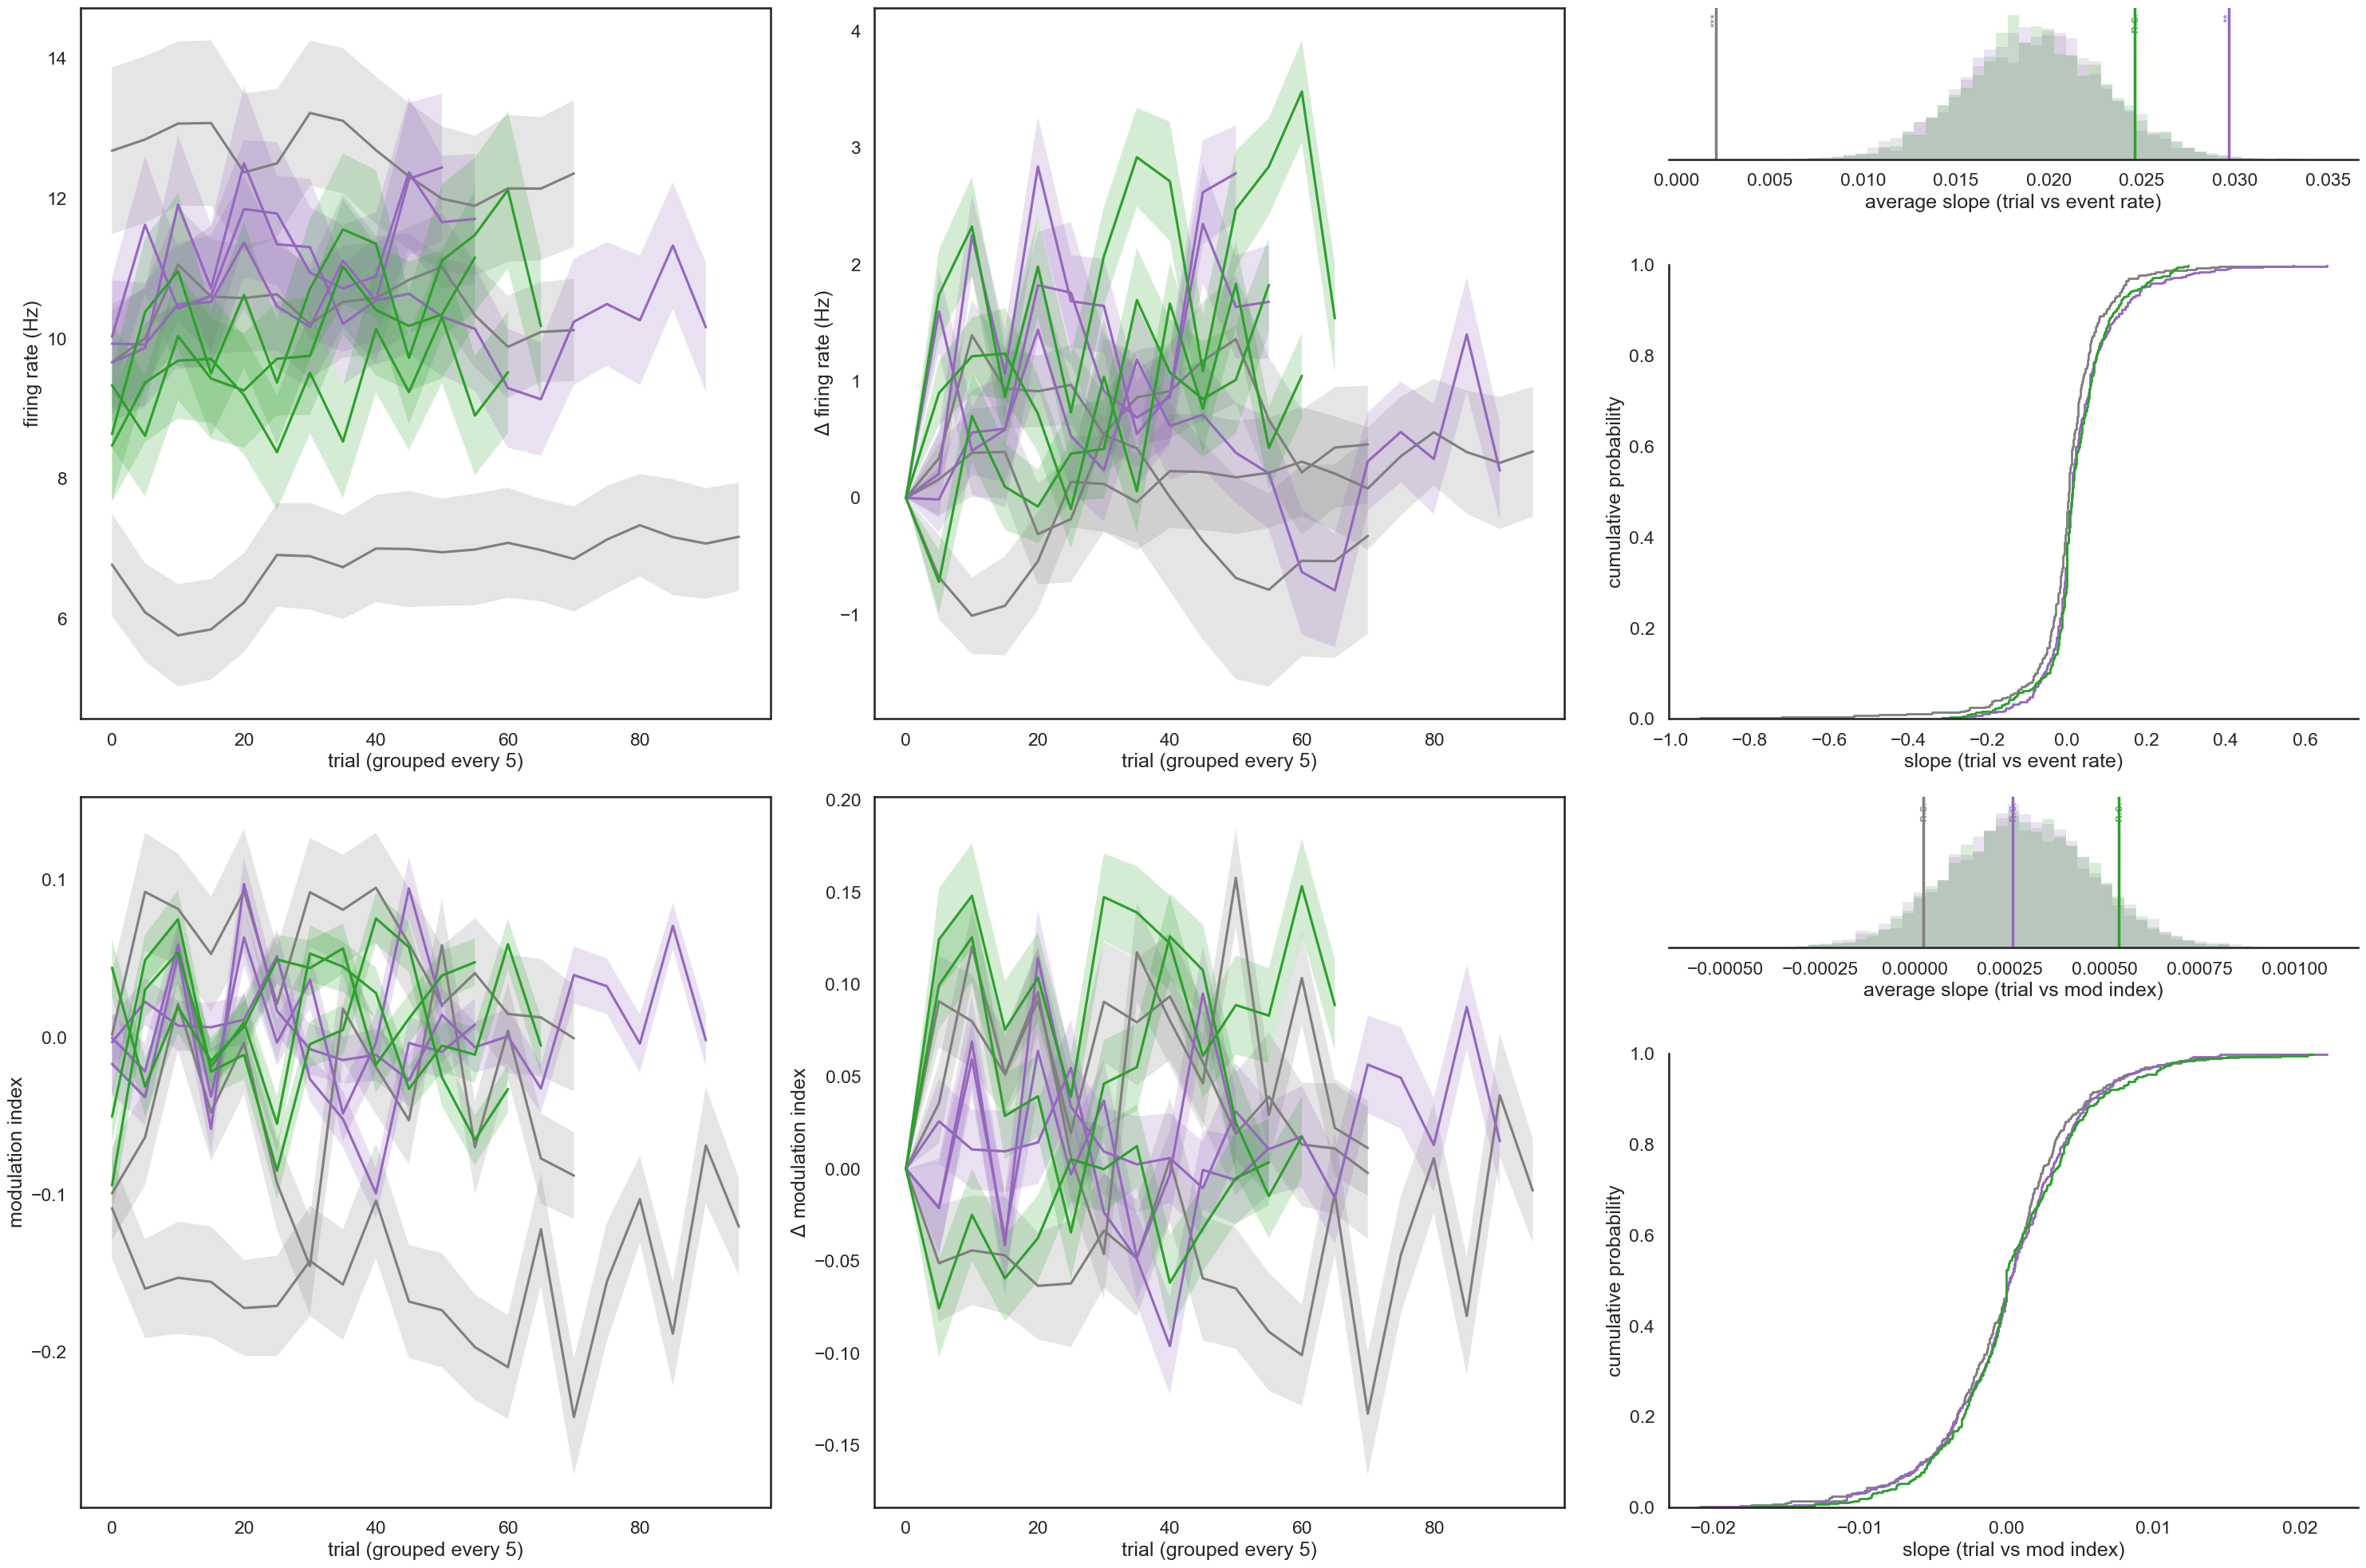

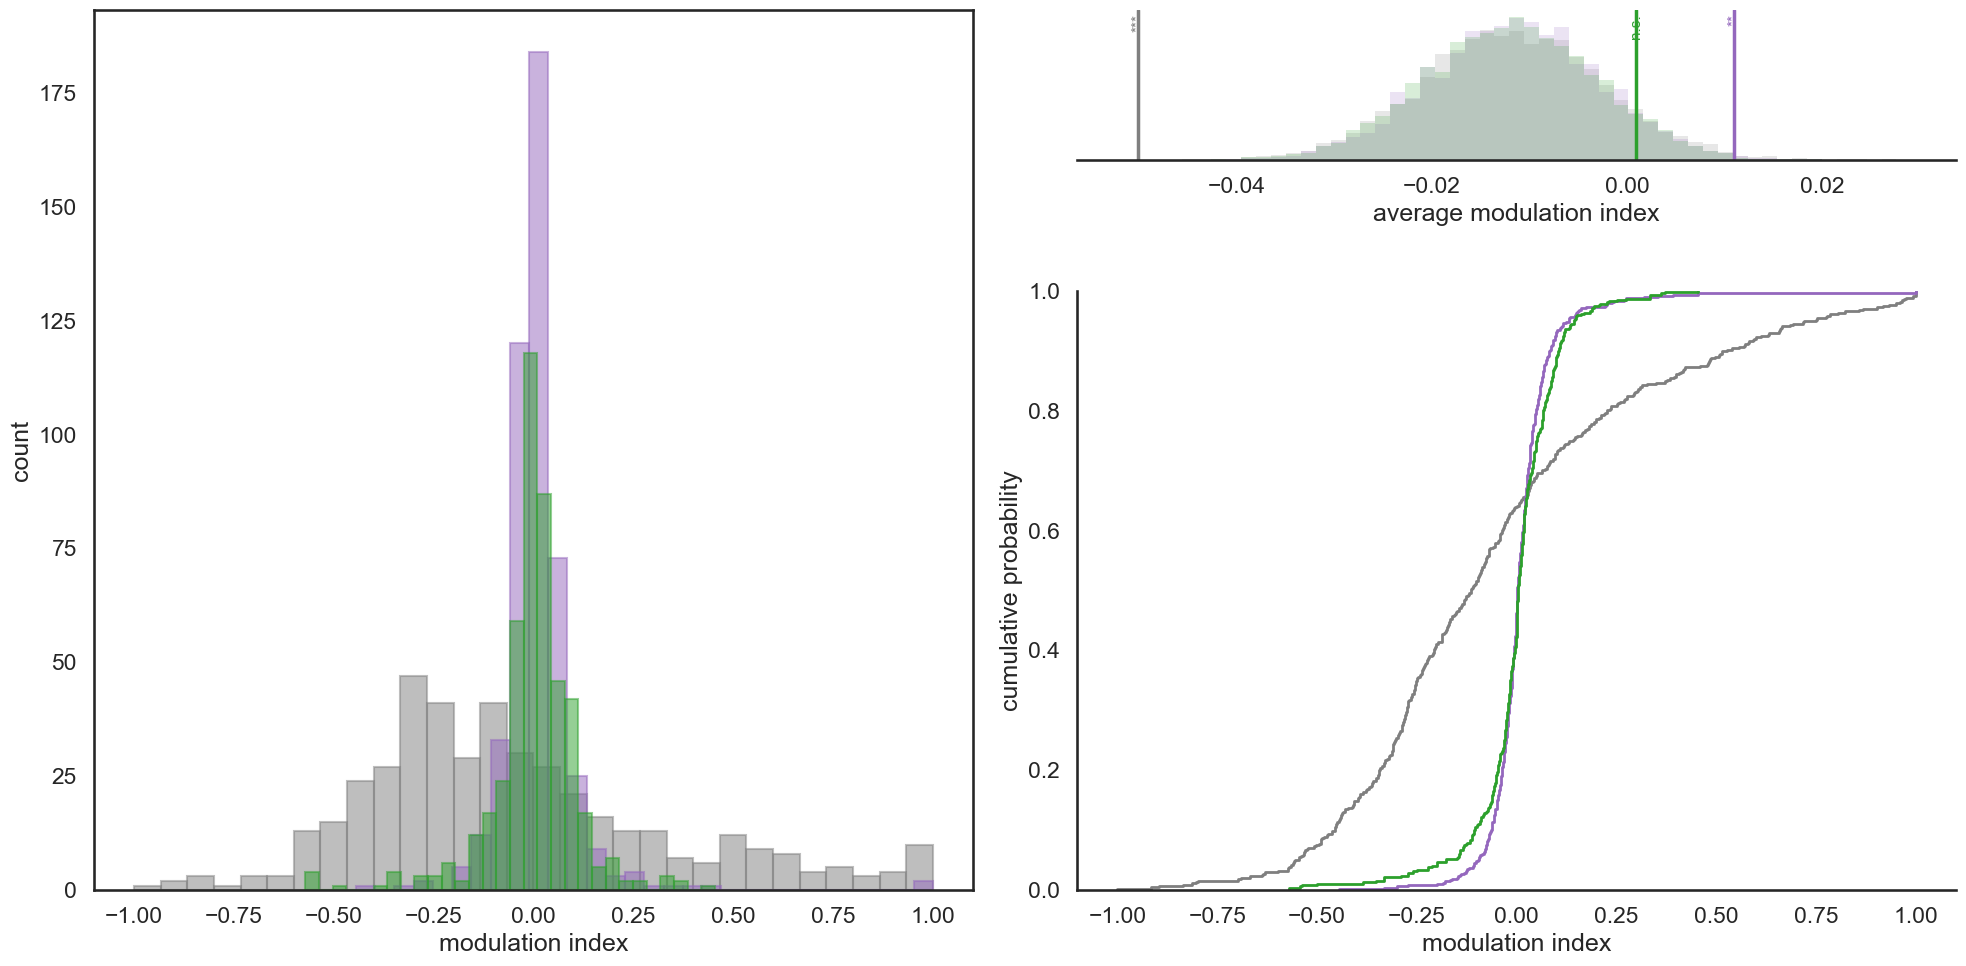

In [ ]:
# Plot trial vs normalized spikes for each unit, with x-axis as individual trial
fig, axs = plt.subplots(2, 3, figsize=(30, 20))

random_color = 'tab:gray'
reward_color = 'tab:green'
punish_color = 'tab:purple'
alpha = 0.5

# Plot grouped event rates (averaged every n_grouped_trials)
for sessions in random_event_rates_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=random_color, ax=axs[0,0])
for sessions in punish_event_rates_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=punish_color, ax=axs[0,0])
for sessions in reward_event_rates_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=reward_color, ax=axs[0,0])
axs[0,0].set_xlabel(f'trial (grouped every {n_grouped_trials})')
axs[0,0].set_ylabel(r'firing rate (Hz)')

# Plot grouped event rates (averaged every n_grouped_trials)
for sessions in random_event_rates_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=random_color, ax=axs[0,1])
for sessions in punish_event_rates_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=punish_color, ax=axs[0,1])
for sessions in reward_event_rates_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=reward_color, ax=axs[0,1])
axs[0,1].set_xlabel(f'trial (grouped every {n_grouped_trials})')
axs[0,1].set_ylabel(r'$\Delta$ firing rate (Hz)')

# Plot distribution of slope (event_rates_diff_grouped vs trial)
random_event_rates_slopes = np.concatenate([np.ravel(x) for x in random_event_rates_slopes])
reward_event_rates_slopes = np.concatenate([np.ravel(x) for x in reward_event_rates_slopes])
punish_event_rates_slopes = np.concatenate([np.ravel(x) for x in punish_event_rates_slopes])
boot_data, boot_idx = ndap.generate_boot_data([random_event_rates_slopes, punish_event_rates_slopes, reward_event_rates_slopes], n_boot=5000)
ndap.plot_distribution(random_event_rates_slopes, boot_data=boot_data, boot_idx=boot_idx[0],
                        color=random_color, label='random', ax=axs[0,2], xlabel='slope (trial vs event rate)')
ndap.plot_distribution(punish_event_rates_slopes, boot_data=boot_data, boot_idx=boot_idx[1],
                        color=punish_color, label='punish', ax=axs[0,2], xlabel='slope (trial vs event rate)')
ndap.plot_distribution(reward_event_rates_slopes, boot_data=boot_data, boot_idx=boot_idx[2],
                        color=reward_color, label='reward', ax=axs[0,2], xlabel='slope (trial vs event rate)')


# Plot grouped event rates (averaged every n_grouped_trials)
for sessions in random_mod_index_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=random_color, ax=axs[1,0])
for sessions in punish_mod_index_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=punish_color, ax=axs[1,0])
for sessions in reward_mod_index_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=reward_color, ax=axs[1,0])
axs[1,0].set_xlabel(f'trial (grouped every {n_grouped_trials})')
axs[1,0].set_ylabel(r'modulation index')

# Plot grouped event rates (averaged every n_grouped_trials)
for sessions in random_mod_index_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=random_color, ax=axs[1,1])
for sessions in punish_mod_index_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=punish_color, ax=axs[1,1])
for sessions in reward_mod_index_diff_grouped:
    # Plot average of all units in sessions
    ndap.plot_sem(sessions, np.arange(sessions.shape[1]) * n_grouped_trials, color=reward_color, ax=axs[1,1])
axs[1,1].set_xlabel(f'trial (grouped every {n_grouped_trials})')
axs[1,1].set_ylabel(r'$\Delta$ modulation index')

# Plot distribution of slope (event_rates_diff_grouped vs trial)
random_mod_index_slopes = np.concatenate([np.ravel(x) for x in random_mod_index_slopes])
reward_mod_index_slopes = np.concatenate([np.ravel(x) for x in reward_mod_index_slopes])
punish_mod_index_slopes = np.concatenate([np.ravel(x) for x in punish_mod_index_slopes])
boot_data, boot_idx = ndap.generate_boot_data([random_mod_index_slopes, punish_mod_index_slopes, reward_mod_index_slopes], n_boot=5000)
ndap.plot_distribution(random_mod_index_slopes, boot_data=boot_data, boot_idx=boot_idx[0],
                        color=random_color, label='random', ax=axs[1,2], xlabel='slope (trial vs mod index)')
ndap.plot_distribution(punish_mod_index_slopes, boot_data=boot_data, boot_idx=boot_idx[1],
                        color=punish_color, label='punish', ax=axs[1,2], xlabel='slope (trial vs mod index)')
ndap.plot_distribution(reward_mod_index_slopes, boot_data=boot_data, boot_idx=boot_idx[2],
                        color=reward_color, label='reward', ax=axs[1,2], xlabel='slope (trial vs mod index)')

plt.tight_layout()
plt.show()

# Save as pdf
fig.savefig(os.path.join(results_folder, f'trial_response_{event_key}_{session_type}.pdf'), dpi=300)


# Plot trial averaged mod index distribution
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Plot distribution of mod index
random_mod_index = np.concatenate([np.ravel(x) for x in random_mod_index])
punish_mod_index = np.concatenate([np.ravel(x) for x in punish_mod_index])
reward_mod_index = np.concatenate([np.ravel(x) for x in reward_mod_index])
axs[0].hist(random_mod_index, bins=30, color=random_color, edgecolor=random_color, alpha=alpha)
axs[0].hist(punish_mod_index, bins=30, color=punish_color, edgecolor=punish_color, alpha=alpha)
axs[0].hist(reward_mod_index, bins=30, color=reward_color, edgecolor=reward_color, alpha=alpha)
axs[0].set_xlabel('modulation index')
axs[0].set_ylabel('count')

boot_data, boot_idx = ndap.generate_boot_data([random_mod_index, punish_mod_index, reward_mod_index], n_boot=5000)
ndap.plot_distribution(random_mod_index, boot_data=boot_data, boot_idx=boot_idx[0],
                        color=random_color, label='random', ax=axs[1], xlabel='modulation index', height_ratios=(1, 4))
ndap.plot_distribution(punish_mod_index, boot_data=boot_data, boot_idx=boot_idx[1],
                        color=punish_color, label='punish', ax=axs[1], xlabel='modulation index', height_ratios=(1, 4))
ndap.plot_distribution(reward_mod_index, boot_data=boot_data, boot_idx=boot_idx[2],
                        color=reward_color, label='reward', ax=axs[1], xlabel='modulation index', height_ratios=(1, 4))

plt.tight_layout()
plt.show()

# Save as pdf
fig.savefig(os.path.join(results_folder, f'mod_index_{event_key}_{session_type}.pdf'), dpi=300)


### Plot lick raster plot for all events

In [57]:
n_events_plot = len(event_types)
fig = plt.figure(figsize=(5 * n_events_plot, 10))
outer_gs = fig.add_gridspec(1, n_events_plot, wspace=0.35)

for col, (event_times, event_name) in enumerate(zip(event_types, event_names)):
    lick_aligned = ndap.get_licks(lick_onsets, event_times, time_range=(-0.5, 2), bin_size_ms=100)

    inner_gs = outer_gs[col].subgridspec(2, 1, height_ratios=[1, 4], hspace=0.05)
    ax_rate   = fig.add_subplot(inner_gs[0])
    ax_raster = fig.add_subplot(inner_gs[1], sharex=ax_rate)

    ndap.plot_sem(lick_aligned['rate'], lick_aligned['xaxis'],
                    plot_individual=False, color='tab:green', ax=ax_rate)
    ax_rate.set_ylabel('Lick rate (Hz)' if col == 0 else '')
    ax_rate.set_title(event_name)
    ax_rate.tick_params(axis='x', labelbottom=False)
    ax_rate.spines['top'].set_visible(False)
    ax_rate.spines['right'].set_visible(False)

    ndap.plot_raster(lick_aligned['times'], lick_aligned['xaxis'],
                        color='tab:green', ax=ax_raster)
    ax_raster.set_xlabel('Time (s)')
    ax_raster.set_ylabel('Trial' if col == 0 else '')
    ax_raster.spines['top'].set_visible(False)
    ax_raster.spines['right'].set_visible(False)

NameError: name 'event_types' is not defined